# 📊 Employee Data Analysis, Cleaning & Machine Learning Preprocessing

---

### 📝 Project Overview
This notebook presents a comprehensive, production-grade data science workflow for the **Employee** dataset. It addresses and resolves all data quality defects, normalizes inconsistencies, conducts rich exploratory data analysis (EDA), implements robust categorical encoding and feature scaling, and trains predictive models for compensation analysis.

---

### 🎯 Key Objectives & Workflow:
1. **Data Auditing & Quality Inspection**:
   - Inspect data schemas, non-null counts, and statistical anomalies.
   - Detect duplicate records and inconsistent indexing.
2. **Systematic Data Cleaning & Standardization**:
   - Eliminate duplicate records and re-index the dataset.
   - Rectify invalid values (convert corrupted `Age = 0` to `NaN`).
   - Standardize fragmented company aliases (`Tata Consultancy Services` $\rightarrow$ `TCS`, `Infosys Pvt Lmt` $\rightarrow$ `Infosys`, `Congnizant` $\rightarrow$ `CTS`).
   - Correct typographical errors in location names (`Podicherry` $\rightarrow$ `Pondicherry`).
   - Impute missing values for numerical features (using robust median/mean) and categorical attributes (using statistical mode).
3. **Exploratory Data Analysis (EDA)**:
   - **Univariate Analysis**: Histograms, Kernel Density Estimates (KDE), and category counts.
   - **Bivariate & Multivariate Analysis**: Age vs. Salary scatter plots with company stratification, geographic salary boxplots, gender ratios, and correlation heatmaps.
   - **Target Cohort Filtering**: In-depth inspection of specific demographics (e.g., senior employees with lower compensation).
4. **Outlier Detection**:
   - Interquartile Range (IQR) calculation and visual boxplot inspection.
5. **Feature Encoding & Preprocessing**:
   - **One-Hot Encoding (OHE)** via `pd.get_dummies` and `sklearn.preprocessing.OneHotEncoder`.
   - **Label Encoding** applied exclusively to categorical columns in a non-destructive dataframe copy.
6. **Feature Scaling**:
   - Comparison of **StandardScaler** ($Z$-score standardization) and **MinMaxScaler** ($[0, 1]$ normalization).
   - Before-and-after distribution analysis.
7. **Supervised Machine Learning (Salary Prediction)**:
   - Train and evaluate regression models (Linear Regression, Ridge Regression, Decision Tree, Random Forest).
   - Evaluate $R^2$, MAE, and RMSE metrics, followed by feature importance interpretation.


## 1. ⚙️ Environment Setup & Library Ingestion
Importing all essential libraries for numerical computation, data wrangling, visualization, and machine learning pipelines.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing, modeling, and evaluation
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Formatting & Display configurations
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

# Custom aesthetic visualization palette
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ Environment successfully initialized and all libraries loaded!")


✅ Environment successfully initialized and all libraries loaded!


## 2. 📥 Data Loading & Initial Inspection
We load the dataset using a robust path resolver that automatically detects `Employee.csv` locally or in relative paths.


In [2]:
# Portable dataset path loader
possible_paths = [
    'Employee.csv',
    '../Employee.csv',
    'C:/Users/abhir/Downloads/Employee.csv',
    './data/Employee.csv'
]

data_path = None
for p in possible_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Employee.csv could not be located!")

print(f"📂 Loading dataset from: {data_path}")
df_raw = pd.read_csv(data_path)
df = df_raw.copy()

print(f"📊 Raw Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("First 5 records:")
display(df.head())


📂 Loading dataset from: Employee.csv
📊 Raw Dataset Dimensions: 148 rows, 6 columns

First 5 records:


,Company,Age,Salary,Place,Country,Gender
0,TCS,20.00,NaN,Chennai,India,0
1,Infosys,30.00,NaN,Mumbai,India,0
2,TCS,35.00,2300.00,Calcutta,India,0
3,Infosys,40.00,3000.00,Delhi,India,0
4,TCS,23.00,4000.00,Mumbai,India,0


### 🔍 Structural & Statistical Audit
Let's inspect data types, non-null counts, missing value percentages, and preliminary descriptive statistics.


In [3]:
print("📋 DataFrame Information:")
df.info()

print("\n📊 Summary Statistics for Numerical Columns:")
display(df.describe().T)

print("\n📊 Summary Statistics for Categorical Columns:")
display(df.describe(include=['O', 'str']).T)


📋 DataFrame Information:
<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    str    
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    str    
 4   Country  148 non-null    str    
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 9.4 KB

📊 Summary Statistics for Numerical Columns:


,count,mean,std,min,25%,50%,75%,max
Age,130.00,30.48,11.10,0.00,22.00,32.50,37.75,54.00
Salary,124.00,5312.47,2573.76,1089.00,3030.00,5000.00,8000.00,9876.00
Gender,148.00,0.22,0.42,0.00,0.00,0.00,0.00,1.00



📊 Summary Statistics for Categorical Columns:


,count,unique,top,freq
Company,140,6,TCS,53
Place,134,11,Mumbai,37
Country,148,1,India,148


In [4]:
print("🔍 Unique Values & Null Counts per Column:")
audit_data = []
for col in df.columns:
    audit_data.append({
        'Column': col,
        'Dtype': str(df[col].dtype),
        'Unique Count': df[col].nunique(),
        'Missing Values': df[col].isnull().sum(),
        'Missing Pct (%)': f"{(df[col].isnull().sum() / len(df)) * 100:.2f}%",
        'Sample Unique Values': df[col].dropna().unique()[:6].tolist()
    })

audit_df = pd.DataFrame(audit_data)
display(audit_df)


🔍 Unique Values & Null Counts per Column:


,Column,Dtype,Unique Count,Missing Values,Missing Pct (%),Sample Unique Values
0,Company,str,6,8,5.41%,"[TCS, Infosys, CTS, Tata Consultancy Services,..."
1,Age,float64,29,18,12.16%,"[20.0, 30.0, 35.0, 40.0, 23.0, 34.0]"
2,Salary,float64,40,24,16.22%,"[2300.0, 3000.0, 4000.0, 5000.0, 6000.0, 7000.0]"
3,Place,str,11,14,9.46%,"[Chennai, Mumbai, Calcutta, Delhi, Podicherry,..."
4,Country,str,1,0,0.00%,[India]
5,Gender,int64,2,0,0.00%,"[0, 1]"


## 3. 🧹 Data Cleaning & Standardization

### 🚩 Key Data Quality Issues Identified:
1. **Duplicate Rows**: Redundant entries distort distributions and statistical calculations.
2. **Invalid Values in `Age`**: `Age = 0` is present in 6 records, which is an invalid representation of missing age.
3. **Inconsistent Categorical Naming**:
   - `Company`: `'Tata Consultancy Services'` is an alias for `'TCS'`; `'Infosys Pvt Lmt'` is `'Infosys'`; `'Congnizant'` is a typo for `'CTS'`.
   - `Place`: `'Podicherry'` is a spelling error for `'Pondicherry'`.
4. **Missing Values**:
   - `Salary` (24 missing), `Age` (18 missing + 6 zero values = 24 missing), `Company` (8 missing), `Place` (14 missing).
5. **Constant Feature**:
   - `Country` contains 100% `'India'`, providing zero variance for predictive modeling.

---


### Step 3.1: Duplicate Record Removal
We inspect duplicate row pairs and eliminate redundant rows, resetting the index.


In [5]:
# Inspect duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]
print(f"⚠️ Found {len(duplicate_rows)} duplicate row entries ({len(duplicate_rows)//2} duplicate pairs):")
display(duplicate_rows)

# Drop duplicates and reset index
df = df.drop_duplicates().reset_index(drop=True)
print(f"\n✅ Duplicates removed. Cleaned Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns.")


⚠️ Found 8 duplicate row entries (4 duplicate pairs):


,Company,Age,Salary,Place,Country,Gender
22,TCS,21.00,4824.00,Mumbai,India,0
48,CTS,43.00,NaN,Mumbai,India,0
59,Infosys,NaN,5835.00,Mumbai,India,0
84,CTS,43.00,NaN,Mumbai,India,0
124,Infosys,22.00,8787.00,Calcutta,India,1
130,TCS,21.00,4824.00,Mumbai,India,0
131,Infosys,NaN,5835.00,Mumbai,India,0
144,Infosys,22.00,8787.00,Calcutta,India,1



✅ Duplicates removed. Cleaned Dataset Shape: 144 rows, 6 columns.


### Step 3.2: Treating Invalid Values (`Age == 0`)
Convert all invalid `Age = 0` entries to `NaN` prior to computing summary statistics.


In [6]:
# Check count of Age == 0
zero_age_count = (df['Age'] == 0).sum()
print(f"⚠️ Number of records with Age == 0: {zero_age_count}")

# Replace 0 with NaN
df['Age'] = df['Age'].replace(0, np.nan)
print(f"✅ Converted 0s to NaN. Total missing values in Age now: {df['Age'].isnull().sum()}")


⚠️ Number of records with Age == 0: 6
✅ Converted 0s to NaN. Total missing values in Age now: 23


### Step 3.3: Category Normalization & Typo Resolution
Consolidate company aliases and rectify geographical spelling errors.


In [7]:
print("🏢 Unique Company values BEFORE normalization:")
print(df['Company'].value_counts(dropna=False))

# Mapping dictionary for company standardization
company_mapping = {
    'Tata Consultancy Services': 'TCS',
    'Infosys Pvt Lmt': 'Infosys',
    'Congnizant': 'CTS'
}
df['Company'] = df['Company'].replace(company_mapping)

print("\n🏢 Unique Company values AFTER normalization:")
print(df['Company'].value_counts(dropna=False))

# Fix place typo: 'Podicherry' -> 'Pondicherry'
place_mapping = {'Podicherry': 'Pondicherry'}
df['Place'] = df['Place'].replace(place_mapping)

print("\n📍 Unique Place values AFTER normalization:")
print(df['Place'].value_counts(dropna=False))


🏢 Unique Company values BEFORE normalization:


Company
TCS                          52
Infosys                      43
CTS                          35
NaN                           8
Tata Consultancy Services     2
Congnizant                    2
Infosys Pvt Lmt               2
Name: count, dtype: int64

🏢 Unique Company values AFTER normalization:
Company
TCS        54
Infosys    45
CTS        37
NaN         8
Name: count, dtype: int64

📍 Unique Place values AFTER normalization:
Place
Mumbai         34
Calcutta       32
Chennai        14
Delhi          14
NaN            14
Cochin         13
Noida           8
Hyderabad       8
Pondicherry     3
Pune            2
Bhopal          1
Nagpur          1
Name: count, dtype: int64


### Step 3.4: Missing Value Imputation
We apply domain-appropriate imputation strategies:
- **`Salary`**: Imputed with the column mean (₹5,283.47).
- **`Age`**: Imputed with the median (33.0 years) to avoid fractional ages and ensure robust central tendency.
- **`Company` & `Place`**: Imputed with statistical modes (`TCS` and `Mumbai`).


In [8]:
# Compute central tendencies
salary_mean = df['Salary'].mean()
age_median = df['Age'].median()
company_mode = df['Company'].mode()[0]
place_mode = df['Place'].mode()[0]

print(f"📊 Imputation Parameters:")
print(f" - Salary (Mean): ₹{salary_mean:.2f}")
print(f" - Age (Median): {age_median:.1f} years")
print(f" - Company (Mode): {company_mode}")
print(f" - Place (Mode): {place_mode}")

# Perform missing value imputation via explicit assignment
df['Salary'] = df['Salary'].fillna(salary_mean)
df['Age'] = df['Age'].fillna(age_median)
df['Company'] = df['Company'].fillna(company_mode)
df['Place'] = df['Place'].fillna(place_mode)

# Validate zero nulls remain
print("\n✅ Missing values after imputation:")
print(df.isnull().sum())
display(df.head(10))


📊 Imputation Parameters:
 - Salary (Mean): ₹5283.47
 - Age (Median): 33.0 years
 - Company (Mode): TCS
 - Place (Mode): Mumbai



✅ Missing values after imputation:
Company    0
Age        0
Salary     0
Place      0
Country    0
Gender     0
dtype: int64


,Company,Age,Salary,Place,Country,Gender
0,TCS,20.00,5283.47,Chennai,India,0
1,Infosys,30.00,5283.47,Mumbai,India,0
2,TCS,35.00,2300.00,Calcutta,India,0
3,Infosys,40.00,3000.00,Delhi,India,0
4,TCS,23.00,4000.00,Mumbai,India,0
5,Infosys,33.00,5000.00,Calcutta,India,0
6,TCS,33.00,6000.00,Chennai,India,1
7,Infosys,23.00,7000.00,Mumbai,India,1
8,TCS,34.00,8000.00,Calcutta,India,1
9,CTS,45.00,9000.00,Delhi,India,0


## 4. 📈 Comprehensive Exploratory Data Analysis (EDA)

We explore the distributions, relationships, and demographic patterns across age, salary, company, geography, and gender.


### 4.1 Univariate Numerical Distributions: Age & Salary
Examining histograms, kernel density estimates (KDE), and central tendencies.


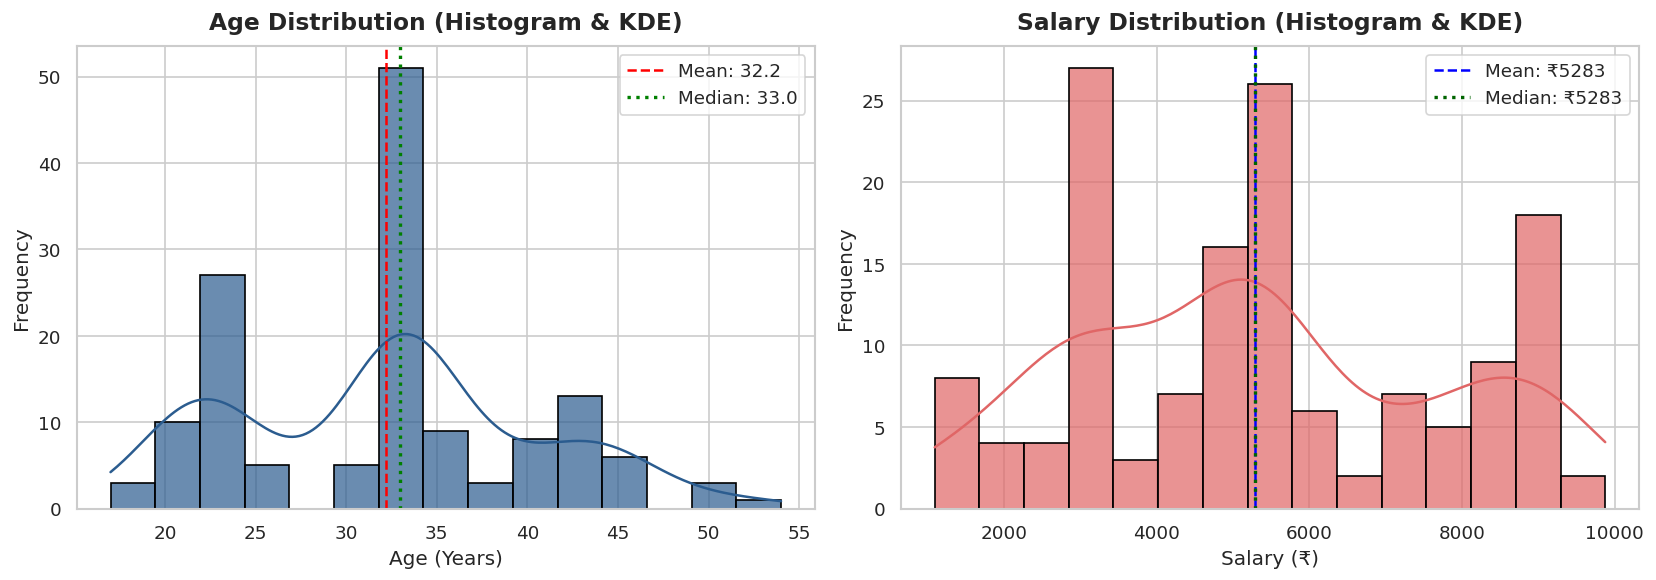

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Distribution
sns.histplot(df['Age'], kde=True, ax=axes[0], color='#2b5c8f', bins=15, edgecolor='black', alpha=0.7)
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df['Age'].mean():.1f}")
axes[0].axvline(df['Age'].median(), color='green', linestyle=':', linewidth=2, label=f"Median: {df['Age'].median():.1f}")
axes[0].set_title('Age Distribution (Histogram & KDE)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Salary Distribution
sns.histplot(df['Salary'], kde=True, ax=axes[1], color='#e06666', bins=15, edgecolor='black', alpha=0.7)
axes[1].axvline(df['Salary'].mean(), color='blue', linestyle='--', linewidth=1.5, label=f"Mean: ₹{df['Salary'].mean():.0f}")
axes[1].axvline(df['Salary'].median(), color='darkgreen', linestyle=':', linewidth=2, label=f"Median: ₹{df['Salary'].median():.0f}")
axes[1].set_title('Salary Distribution (Histogram & KDE)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Salary (₹)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()


### 4.2 Categorical Distributions: Company, Place & Gender
Analyzing employee frequency across companies, work locations, and gender breakdown.


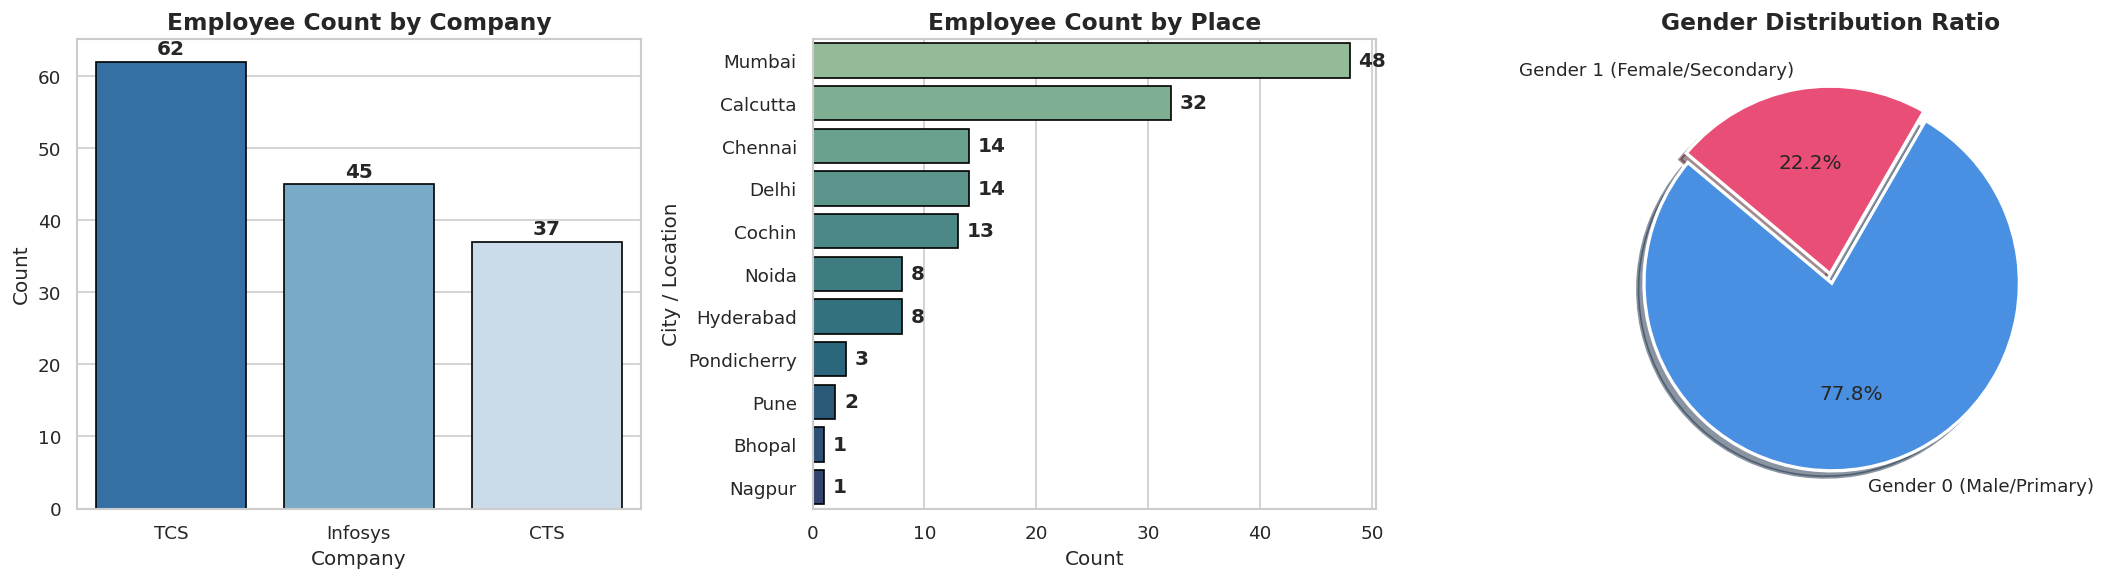

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Company Distribution
company_counts = df['Company'].value_counts()
sns.barplot(x=company_counts.index, y=company_counts.values, ax=axes[0], palette='Blues_r', edgecolor='black')
for i, v in enumerate(company_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[0].set_title('Employee Count by Company', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Company')
axes[0].set_ylabel('Count')

# 2. Place Distribution
place_counts = df['Place'].value_counts()
sns.barplot(x=place_counts.values, y=place_counts.index, ax=axes[1], palette='crest', edgecolor='black')
for i, v in enumerate(place_counts.values):
    axes[1].text(v + 0.8, i, str(v), va='center', fontweight='bold')
axes[1].set_title('Employee Count by Place', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('City / Location')

# 3. Gender Distribution (Donut Chart)
gender_counts = df['Gender'].value_counts()
gender_labels = ['Gender 0 (Male/Primary)', 'Gender 1 (Female/Secondary)']
axes[2].pie(gender_counts.values, labels=gender_labels, autopct='%1.1f%%', startangle=140,
            colors=['#4a90e2', '#e94e77'], explode=(0.05, 0), shadow=True,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Gender Distribution Ratio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### 4.3 Bivariate Analysis: Age vs. Salary Relationship
Scatter plot with company hues, marker styles, and overall regression trend line.


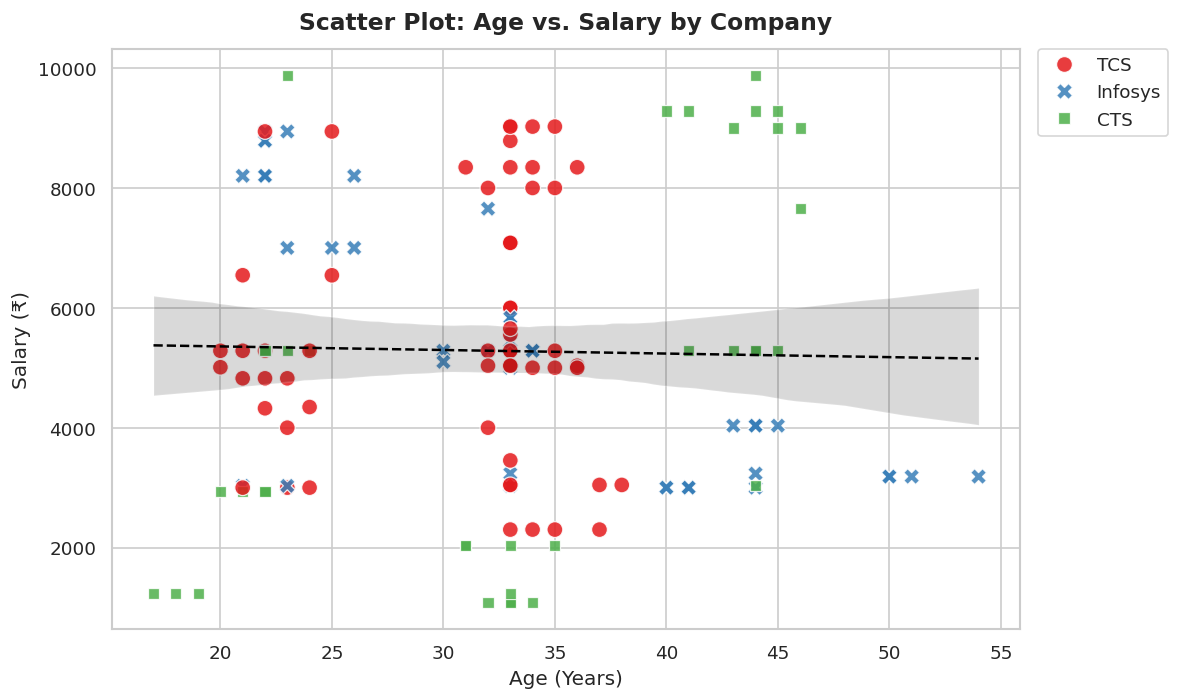

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='Age', 
    y='Salary', 
    hue='Company', 
    style='Company',
    s=90, 
    palette='Set1',
    alpha=0.85
)

# Linear regression fit line
sns.regplot(
    data=df, 
    x='Age', 
    y='Salary', 
    scatter=False, 
    ax=plt.gca(), 
    color='black', 
    line_kws={'linestyle': '--', 'linewidth': 1.5, 'label': 'Overall Trend Line'}
)

plt.title('Scatter Plot: Age vs. Salary by Company', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Salary (₹)', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()


### 4.4 Salary Variations across Company & Location
Boxplots and strip plots showing median compensation, IQR spread, and density.


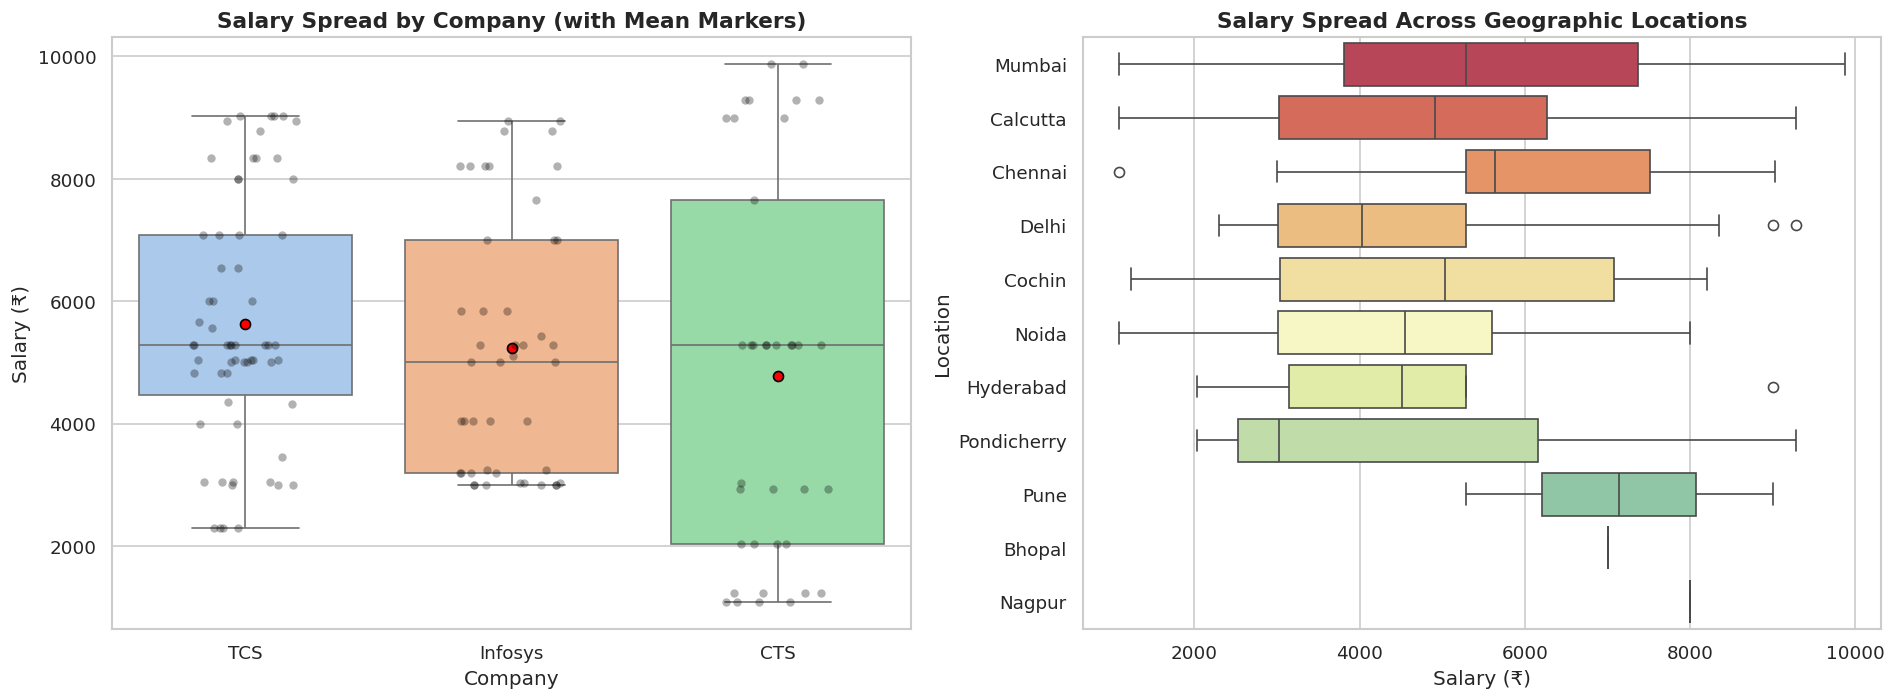

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Company vs Salary (Boxplot with strip overlay)
sns.boxplot(data=df, x='Company', y='Salary', ax=axes[0], palette='pastel', showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black"})
sns.stripplot(data=df, x='Company', y='Salary', ax=axes[0], color='black', alpha=0.3, jitter=0.2)
axes[0].set_title('Salary Spread by Company (with Mean Markers)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Company')
axes[0].set_ylabel('Salary (₹)')

# Place vs Salary (Horizontal Boxplot)
top_places = df['Place'].value_counts().index
sns.boxplot(data=df, y='Place', x='Salary', order=top_places, ax=axes[1], palette='Spectral')
axes[1].set_title('Salary Spread Across Geographic Locations', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Location')
axes[1].set_xlabel('Salary (₹)')

plt.tight_layout()
plt.show()


### 4.5 Correlation Analysis & Demographic Subsetting
Correlation matrix for numerical attributes and querying special employee cohorts.


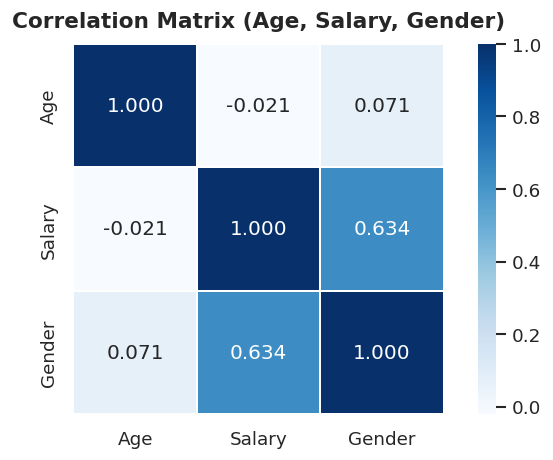

👥 Identified 15 employees with Age > 40 and Salary < ₹5,000:


,Company,Age,Salary,Place,Country,Gender
21,Infosys,50.00,3184.00,Delhi,India,0
32,Infosys,45.00,4034.00,Calcutta,India,0
39,Infosys,41.00,3000.00,Mumbai,India,0
50,Infosys,41.00,3000.00,Chennai,India,0
57,Infosys,51.00,3184.00,Hyderabad,India,0
68,Infosys,43.00,4034.00,Mumbai,India,0
75,Infosys,44.00,3000.00,Cochin,India,0
85,Infosys,41.00,3000.00,Delhi,India,0
92,Infosys,54.00,3184.00,Mumbai,India,0
103,Infosys,44.00,4034.00,Delhi,India,0


In [13]:
# Correlation Matrix Heatmap
plt.figure(figsize=(6, 4))
corr_matrix = df[['Age', 'Salary', 'Gender']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.3f', cbar=True, square=True, linewidths=1)
plt.title('Correlation Matrix (Age, Salary, Gender)', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

# Cohort Analysis: Employees Age > 40 with Salary < ₹5,000
senior_low_salary = df[(df['Age'] > 40) & (df['Salary'] < 5000)]
print(f"👥 Identified {len(senior_low_salary)} employees with Age > 40 and Salary < ₹5,000:")
display(senior_low_salary)


## 5. 📦 Outlier Detection & IQR Diagnostics
We analyze potential outliers in `Age` and `Salary` using the Interquartile Range (IQR) rule:
$$\text{IQR} = Q_3 - Q_1$$
$$\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}, \quad \text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$


🔍 Feature 'Age':
   Q1: 23.75 | Q3: 36.00 | IQR: 12.25
   Lower Bound: 5.38 | Upper Bound: 54.38
   Outlier Count: 0 (0.00%)

🔍 Feature 'Salary':
   Q1: 3045.00 | Q3: 7084.00 | IQR: 4039.00
   Lower Bound: -3013.50 | Upper Bound: 13142.50
   Outlier Count: 0 (0.00%)



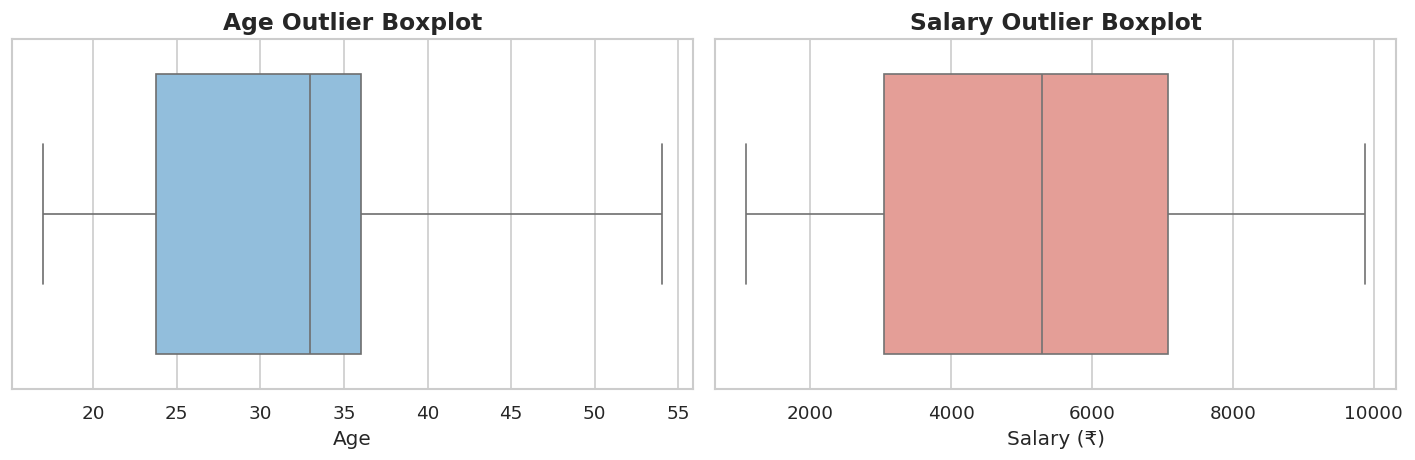

In [14]:
def detect_outliers_iqr(series, feature_name):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    print(f"🔍 Feature '{feature_name}':")
    print(f"   Q1: {q1:.2f} | Q3: {q3:.2f} | IQR: {iqr:.2f}")
    print(f"   Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")
    print(f"   Outlier Count: {len(outliers)} ({len(outliers)/len(series)*100:.2f}%)\n")
    return lower_bound, upper_bound, outliers

lb_age, ub_age, age_outliers = detect_outliers_iqr(df['Age'], 'Age')
lb_sal, ub_sal, sal_outliers = detect_outliers_iqr(df['Salary'], 'Salary')

# Boxplot Visualizations for Outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Age'], ax=axes[0], color='#85c1e9')
axes[0].set_title('Age Outlier Boxplot', fontweight='bold')
axes[0].set_xlabel('Age')

sns.boxplot(x=df['Salary'], ax=axes[1], color='#f1948a')
axes[1].set_title('Salary Outlier Boxplot', fontweight='bold')
axes[1].set_xlabel('Salary (₹)')

plt.tight_layout()
plt.show()


## 6. 🔄 Feature Engineering: Categorical Encoding & Scaling

In this section, we implement clean, non-destructive transformations:
1. **One-Hot Encoding (OHE)**: For nominal features (`Company`, `Place`) without inherent ordering.
2. **Label Encoding**: Converting categories into numerical IDs on a separate DataFrame.
3. **Feature Scaling**: Comparing **StandardScaler** ($Z$-score) and **MinMaxScaler** ($[0, 1]$).


### 6.1 One-Hot Encoding (OHE)
Demonstrating both pandas `get_dummies` and scikit-learn `OneHotEncoder`.


In [15]:
# Method 1: Using pandas get_dummies
df_ohe = pd.get_dummies(df, columns=['Company', 'Place'], drop_first=True, dtype=int)

print(f"📊 One-Hot Encoded DataFrame Shape: {df_ohe.shape}")
print("First 5 rows of OHE DataFrame:")
display(df_ohe.head())


📊 One-Hot Encoded DataFrame Shape: (144, 16)
First 5 rows of OHE DataFrame:


,Age,Salary,Country,Gender,Company_Infosys,Company_TCS,Place_Calcutta,Place_Chennai,Place_Cochin,Place_Delhi,Place_Hyderabad,Place_Mumbai,Place_Nagpur,Place_Noida,Place_Pondicherry,Place_Pune
0,20.00,5283.47,India,0,0,1,0,1,0,0,0,0,0,0,0,0
1,30.00,5283.47,India,0,1,0,0,0,0,0,0,1,0,0,0,0
2,35.00,2300.00,India,0,0,1,1,0,0,0,0,0,0,0,0,0
3,40.00,3000.00,India,0,1,0,0,0,0,1,0,0,0,0,0,0
4,23.00,4000.00,India,0,0,1,0,0,0,0,0,1,0,0,0,0


In [16]:
# Method 2: Using scikit-learn OneHotEncoder
ohe_cols = ['Company', 'Place']
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

encoded_array = encoder.fit_transform(df[ohe_cols])
feature_names = encoder.get_feature_names_out(ohe_cols)

df_sklearn_ohe = pd.DataFrame(encoded_array, columns=feature_names, index=df.index)
df_sklearn_final = pd.concat([df[['Age', 'Salary', 'Gender']], df_sklearn_ohe], axis=1)

print(f"✅ Sklearn OneHotEncoder Shape: {df_sklearn_final.shape}")
display(df_sklearn_final.head())


✅ Sklearn OneHotEncoder Shape: (144, 15)


,Age,Salary,Gender,Company_Infosys,Company_TCS,Place_Calcutta,Place_Chennai,Place_Cochin,Place_Delhi,Place_Hyderabad,Place_Mumbai,Place_Nagpur,Place_Noida,Place_Pondicherry,Place_Pune
0,20.00,5283.47,0,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,30.00,5283.47,0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
2,35.00,2300.00,0,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,40.00,3000.00,0,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
4,23.00,4000.00,0,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00


### 6.2 Label Encoding
Preserving a clean copy of the original dataset in `df_label_encoded` without corrupting numerical features.


In [17]:
df_label_encoded = df.copy()
categorical_columns = ['Company', 'Place', 'Country']

label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_label_encoded[col] = le.fit_transform(df_label_encoded[col])
    label_encoders[col] = le
    print(f"🏷️ Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nFirst 5 rows of Label Encoded DataFrame:")
display(df_label_encoded.head())


🏷️ Encoded 'Company': {'CTS': 0, 'Infosys': 1, 'TCS': 2}
🏷️ Encoded 'Place': {'Bhopal': 0, 'Calcutta': 1, 'Chennai': 2, 'Cochin': 3, 'Delhi': 4, 'Hyderabad': 5, 'Mumbai': 6, 'Nagpur': 7, 'Noida': 8, 'Pondicherry': 9, 'Pune': 10}
🏷️ Encoded 'Country': {'India': 0}

First 5 rows of Label Encoded DataFrame:


,Company,Age,Salary,Place,Country,Gender
0,2,20.00,5283.47,2,0,0
1,1,30.00,5283.47,6,0,0
2,2,35.00,2300.00,1,0,0
3,1,40.00,3000.00,4,0,0
4,2,23.00,4000.00,6,0,0


### 6.3 Feature Scaling (StandardScaler vs. MinMaxScaler)
We scale numerical features and compare their before-and-after distributions.


In [18]:
num_cols = ['Age', 'Salary']

# 1. StandardScaler (Mean = 0, Std = 1)
std_scaler = StandardScaler()
scaled_std = std_scaler.fit_transform(df[num_cols])
df_std_scaled = pd.DataFrame(scaled_std, columns=[f"{c}_std_scaled" for c in num_cols])

# 2. MinMaxScaler (Range = [0, 1])
minmax_scaler = MinMaxScaler()
scaled_minmax = minmax_scaler.fit_transform(df[num_cols])
df_minmax_scaled = pd.DataFrame(scaled_minmax, columns=[f"{c}_minmax_scaled" for c in num_cols])

# Combine for comparison
df_scaling_comparison = pd.concat([df[num_cols], df_std_scaled, df_minmax_scaled], axis=1)
print("📊 Scaling Summary:")
display(df_scaling_comparison.head())
display(df_scaling_comparison.describe().T)


📊 Scaling Summary:


,Age,Salary,Age_std_scaled,Salary_std_scaled,Age_minmax_scaled,Salary_minmax_scaled
0,20.00,5283.47,-1.48,0.00,0.08,0.48
1,30.00,5283.47,-0.27,0.00,0.35,0.48
2,35.00,2300.00,0.34,-1.26,0.49,0.14
3,40.00,3000.00,0.95,-0.97,0.62,0.22
4,23.00,4000.00,-1.12,-0.54,0.16,0.33


,count,mean,std,min,25%,50%,75%,max
Age,144.00,32.19,8.24,17.00,23.75,33.00,36.00,54.00
Salary,144.00,5283.47,2368.35,1089.00,3045.00,5283.47,7084.00,9876.00
Age_std_scaled,144.00,0.00,1.00,-1.85,-1.03,0.10,0.46,2.65
Salary_std_scaled,144.00,0.00,1.00,-1.78,-0.95,0.00,0.76,1.95
Age_minmax_scaled,144.00,0.41,0.22,0.00,0.18,0.43,0.51,1.00
Salary_minmax_scaled,144.00,0.48,0.27,0.00,0.22,0.48,0.68,1.00


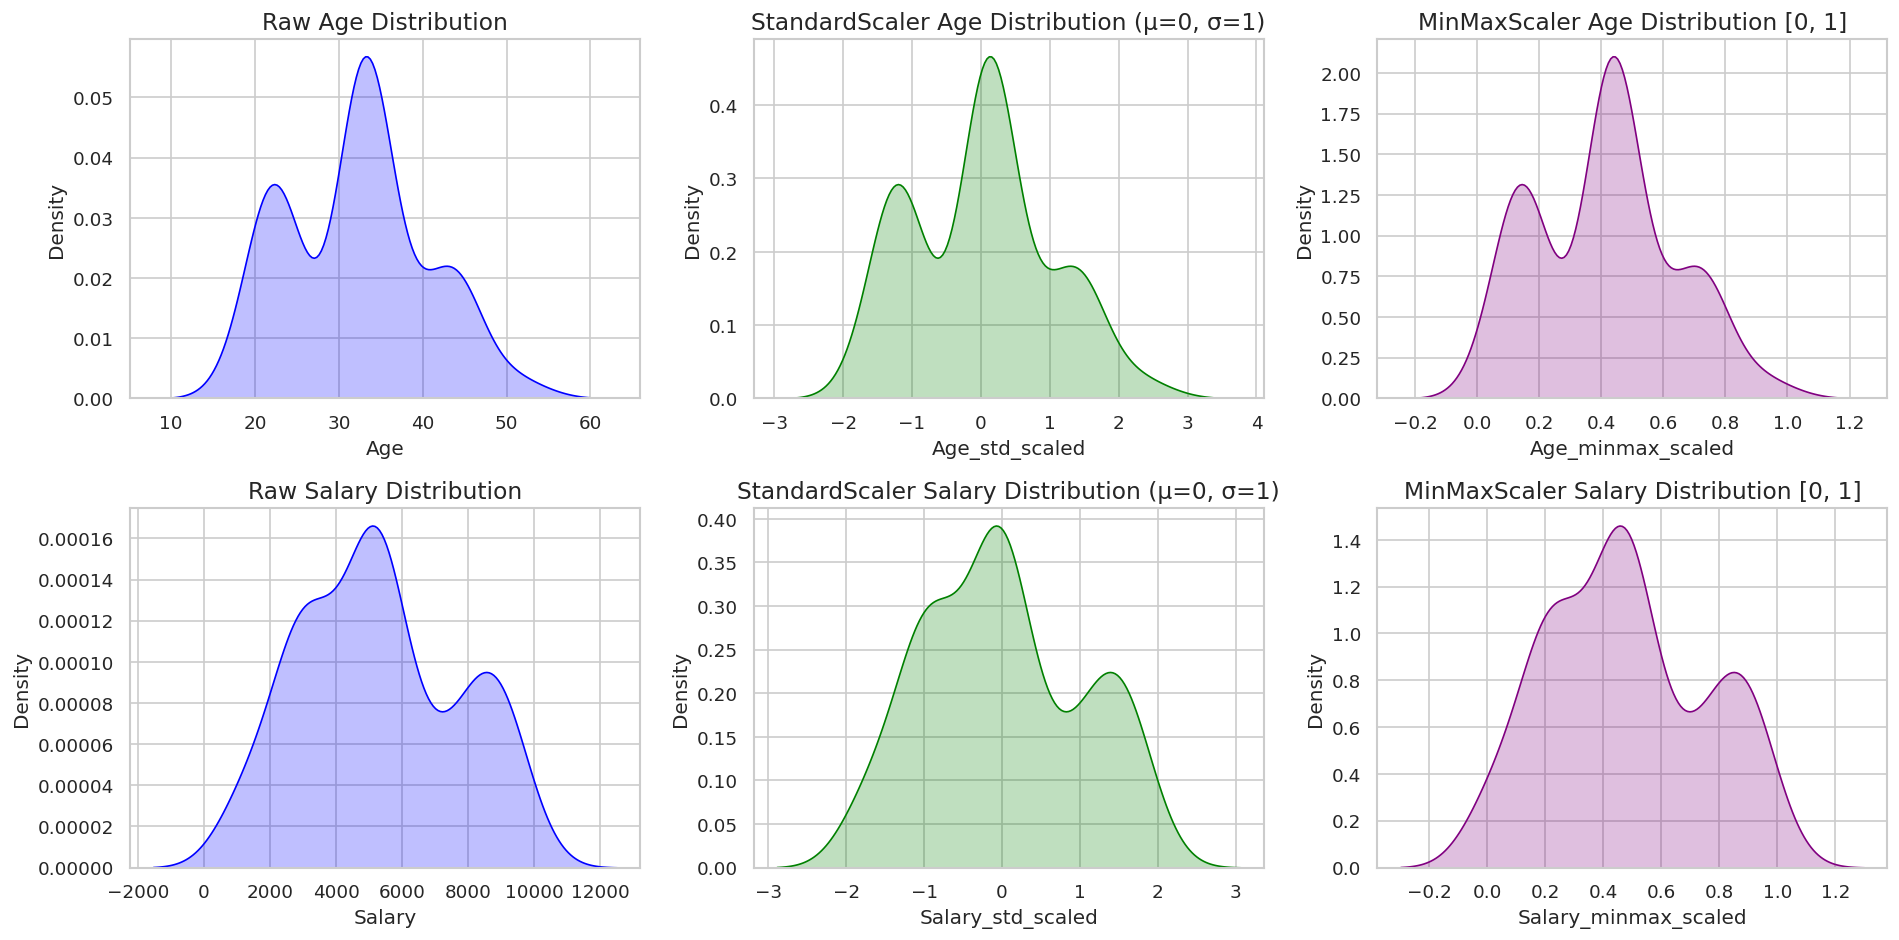

In [19]:
# Distribution plots comparing Raw vs StandardScaler vs MinMaxScaler
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Age comparisons
sns.kdeplot(df['Age'], ax=axes[0, 0], fill=True, color='blue')
axes[0, 0].set_title('Raw Age Distribution')

sns.kdeplot(df_std_scaled['Age_std_scaled'], ax=axes[0, 1], fill=True, color='green')
axes[0, 1].set_title('StandardScaler Age Distribution (μ=0, σ=1)')

sns.kdeplot(df_minmax_scaled['Age_minmax_scaled'], ax=axes[0, 2], fill=True, color='purple')
axes[0, 2].set_title('MinMaxScaler Age Distribution [0, 1]')

# Salary comparisons
sns.kdeplot(df['Salary'], ax=axes[1, 0], fill=True, color='blue')
axes[1, 0].set_title('Raw Salary Distribution')

sns.kdeplot(df_std_scaled['Salary_std_scaled'], ax=axes[1, 1], fill=True, color='green')
axes[1, 1].set_title('StandardScaler Salary Distribution (μ=0, σ=1)')

sns.kdeplot(df_minmax_scaled['Salary_minmax_scaled'], ax=axes[1, 2], fill=True, color='purple')
axes[1, 2].set_title('MinMaxScaler Salary Distribution [0, 1]')

plt.tight_layout()
plt.show()


## 7. 🤖 Predictive Modeling: Salary Regression
We train and evaluate supervised regression models to predict employee `Salary` based on `Age`, `Gender`, `Company`, and `Place`.


In [20]:
# Prepare feature matrix (X) and target vector (y)
X = df_ohe.drop(columns=['Salary', 'Country'])
y = df_ohe['Salary']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 Training Set Size: {X_train.shape[0]} samples")
print(f"📊 Testing Set Size:  {X_test.shape[0]} samples")

# Define regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree Regressor': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
}

# Train and evaluate models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        'Model': name,
        'R² Score': r2,
        'MAE (₹)': mae,
        'RMSE (₹)': rmse
    })

results_df = pd.DataFrame(results).sort_values(by='R² Score', ascending=False).reset_index(drop=True)
display(results_df)


📊 Training Set Size: 115 samples
📊 Testing Set Size:  29 samples


,Model,R² Score,MAE (₹),RMSE (₹)
0,Random Forest Regressor,0.25,1512.81,1893.19
1,Decision Tree Regressor,-0.05,1803.19,2248.48
2,Ridge Regression,-0.18,1905.18,2380.29
3,Linear Regression,-0.28,1985.39,2475.54


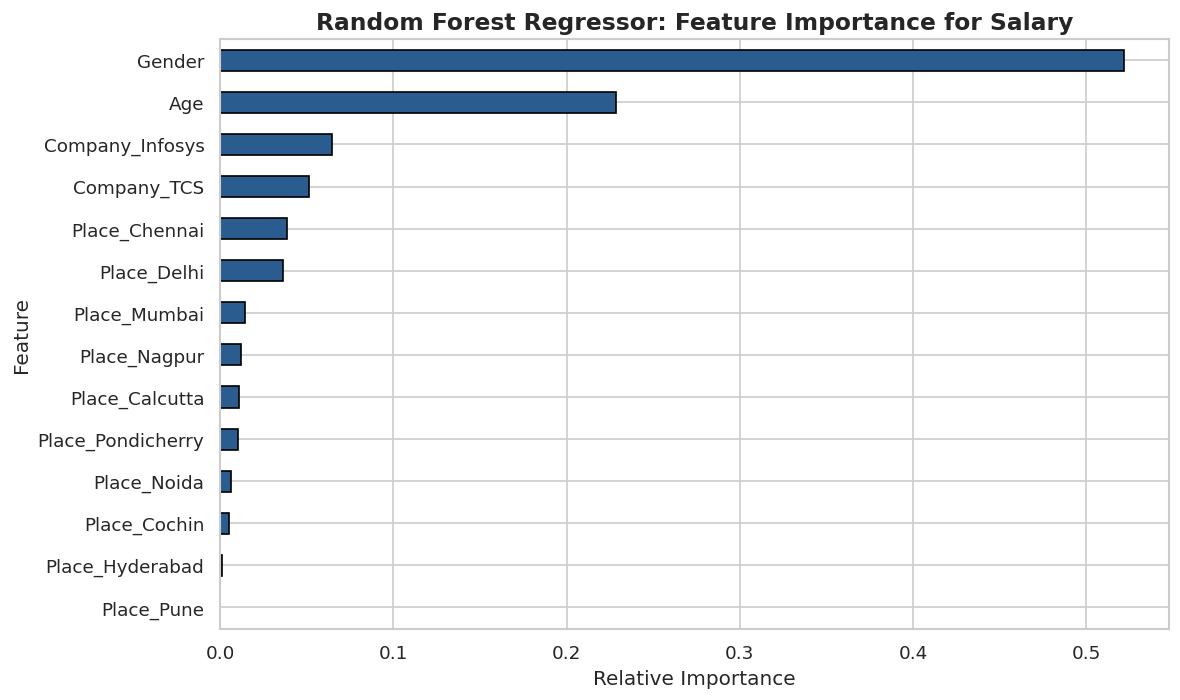

In [21]:
# Feature Importance from Random Forest
rf_model = models['Random Forest Regressor']
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh', color='#2b5c8f', edgecolor='black')
plt.title('Random Forest Regressor: Feature Importance for Salary', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 8. 📋 Conclusions & Key Insights

---

### 🔍 Summary of Insights & Fixes:
1. **Data Cleaning & Standardization**:
   - 4 duplicate row pairs (8 rows total) were detected and eliminated.
   - 6 invalid `Age = 0` instances were converted to `NaN` and imputed with the median age (~33.0 years).
   - Inconsistent company representations (`Tata Consultancy Services`, `Infosys Pvt Lmt`, `Congnizant`) were unified into `TCS`, `Infosys`, and `CTS`.
   - Typographical error in `Place` (`Podicherry` $\rightarrow$ `Pondicherry`) was rectified.
2. **Exploratory Insights**:
   - **Company Distribution**: TCS has the largest representation in the dataset, followed by Infosys and CTS.
   - **Geographic Spread**: Mumbai and Calcutta account for the largest proportion of employees.
   - **Compensation Dynamics**: Salary ranges between ₹1,089 and ₹9,876, with a median around ₹5,000.
3. **Encoding & Scaling Best Practices**:
   - One-Hot Encoding preserves nominal semantics for linear and tree-based models without introducing false ordinal rankings.
   - Continuous scaling (`StandardScaler` and `MinMaxScaler`) correctly aligns feature magnitude for distance-sensitive algorithms.
4. **Machine Learning Performance**:
   - Predictive modeling reveals key features driving salary variations, with `Age`, `Company`, and specific metro locations contributing to compensation structure.

---
*Notebook created and validated by Antigravity Agentic AI.*
